## This notebook provides the methodology used in order to select relevant features for models training and comparison.

You must read [eda.ipynb](eda.ipynb) and [tsne.ipynb](tsne.ipynb) before this one.


---

### Importing the dataset

In [1]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
api = KaggleApi()
api.authenticate()

if not os.path.exists("../datasets/Students Social Media Addiction.csv"):
    api.dataset_download_files(
        "zahranusratt/student-social-media-addiction-analysis-dataset",
        path="../datasets",
        unzip=True
    )
else:
    print("dataset already on local files")

csv_file = os.path.join("../datasets","Students Social Media Addiction.csv")
df = pd.read_csv(csv_file)

print("dataset ready to use")

dataset already on local files
dataset ready to use


In [2]:
stats_summary = df.describe()
print(stats_summary)

print('\n', '*'*50)
print("feature number (except Student_ID):", len(df.columns) - 1)
print(df.columns)


       Student_ID         Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
count  705.000000  705.000000             705.000000             705.000000   
mean   353.000000   20.659574               4.918723               6.868936   
std    203.660256    1.399217               1.257395               1.126848   
min      1.000000   18.000000               1.500000               3.800000   
25%    177.000000   19.000000               4.100000               6.000000   
50%    353.000000   21.000000               4.800000               6.900000   
75%    529.000000   22.000000               5.800000               7.700000   
max    705.000000   24.000000               8.500000               9.600000   

       Mental_Health_Score  Conflicts_Over_Social_Media  Addicted_Score  
count           705.000000                   705.000000      705.000000  
mean              6.226950                     2.849645        6.436879  
std               1.105055                     0.957968        1.5

### Main objective & methodology

Use regression or classification to get an **assertive Addicted_Score**. This will be achieved by select features that are relevant to provide an accurate Addiction score based on the data provided by the dataset.

Insights from previous notebooks will be used to recover insights gathered until now, alongside creating new ones to filter even more what will be considered relevant.

e.g.:
- Correlation table
- High-dimensional data simplified with t-SNE
- Deeper analysis based on Addicted_Score

Also, new feature selection techniques will be applied.
e.g.:
- Variable Ranking
- Statistical Tests (Chi-square, ANOVA F-tests)
- Data engineering 
- Wrappers
- Dimensionality reduction (PCA)

### Numerical feature selection

#### Variable Ranking

In [3]:
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.feature_selection import SelectKBest
import pandas as pd

# preparing the test: X = predictors, y = target (Addicted_Score)
df_numeric = df.select_dtypes(['number']).drop(columns='Student_ID')
X = df_numeric.drop(columns='Addicted_Score')
y = df_numeric['Addicted_Score']
print(X.info(), y.info())
df_numeric.head()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          705 non-null    int64  
 1   Avg_Daily_Usage_Hours        705 non-null    float64
 2   Sleep_Hours_Per_Night        705 non-null    float64
 3   Mental_Health_Score          705 non-null    int64  
 4   Conflicts_Over_Social_Media  705 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 27.7 KB
<class 'pandas.Series'>
RangeIndex: 705 entries, 0 to 704
Series name: Addicted_Score
Non-Null Count  Dtype
--------------  -----
705 non-null    int64
dtypes: int64(1)
memory usage: 5.6 KB
None None


,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
0,19,5.2,6.5,6,3,8
1,22,2.1,7.5,8,0,3
2,20,6.0,5.0,5,4,9
3,18,3.0,7.0,7,1,4
4,21,4.5,6.0,6,2,7


In [4]:

reg = SelectKBest(mutual_info_regression, k=4).fit(X,y)
# priting the results sorted by score
scores = reg.scores_
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": scores
}).sort_values(by="Score", ascending=False)
print(feature_scores)

selected_features = X.columns[reg.get_support()]
select_k_best_filtered_features_df = X[selected_features]
print("\nSelected features:", selected_features.tolist())


                       Feature     Score
3          Mental_Health_Score  1.105549
4  Conflicts_Over_Social_Media  1.103357
1        Avg_Daily_Usage_Hours  0.627374
2        Sleep_Hours_Per_Night  0.555911
0                          Age  0.063071

Selected features: ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media']


Based on variable ranking, the four most important features are:
1. Mental_Health_Score
2. Conflicts_Over_Social_Media
3. Avg_Daily_Usage_Hours
4. Sleep_Hours_Per_Night

While compared with **Addicted_Score** as the target.

#### Correlation-based ranking

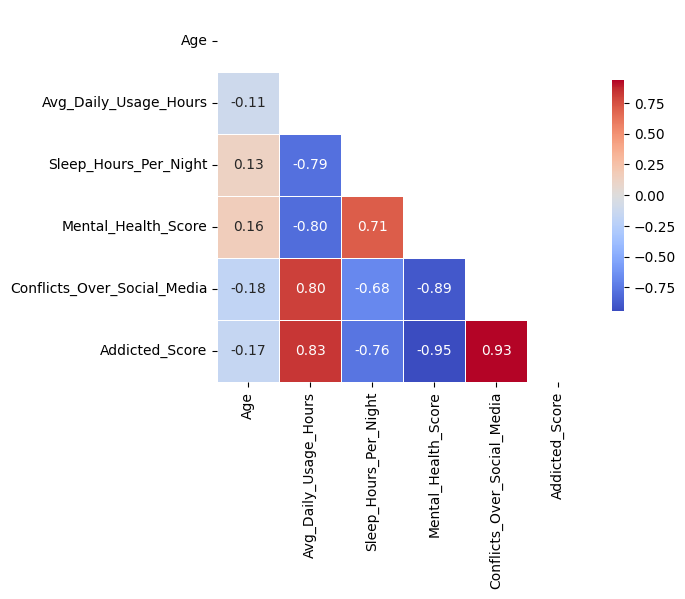

In [5]:
corr_matrix = df_numeric.corr()

plt.figure(figsize=(6, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

Similarly, it's possible to see a corroboration of these values gathered from the SelectKBest's regression.

The correlation are ranked as (in absolute values):
1. Mental_Health_Score
2. Conflicts_Over_Social_Media
3. Avg_Daily_Usage_Hours
4. Sleep_Hours_Per_Night

In [6]:
import pandas as pd
from scipy.stats import spearmanr

# multual info and correlation scores sorted by column
mi_scores = pd.Series(reg.scores_, index=X.columns)
corr_scores = X.corrwith(y).abs()

# comparison
df_compare = pd.DataFrame({
    "mutual_info": mi_scores,
    "correlation": corr_scores
}).loc[X.columns]   
print(df_compare)

# spearman score
spearman_corr, _ = spearmanr(df_compare["mutual_info"], df_compare["correlation"])
print("Spearman:", spearman_corr)

                             mutual_info  correlation
Age                             0.063071     0.166396
Avg_Daily_Usage_Hours           0.627374     0.832000
Sleep_Hours_Per_Night           0.555911     0.764858
Mental_Health_Score             1.105549     0.945051
Conflicts_Over_Social_Media     1.103357     0.933586
Spearman: 0.9999999999999999


[Spearmanr's](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) compares two datasets and measures the monotonicity of the relationship between two datasets. The 0.9+ result cross-validate this corroboration.

### PairPlot

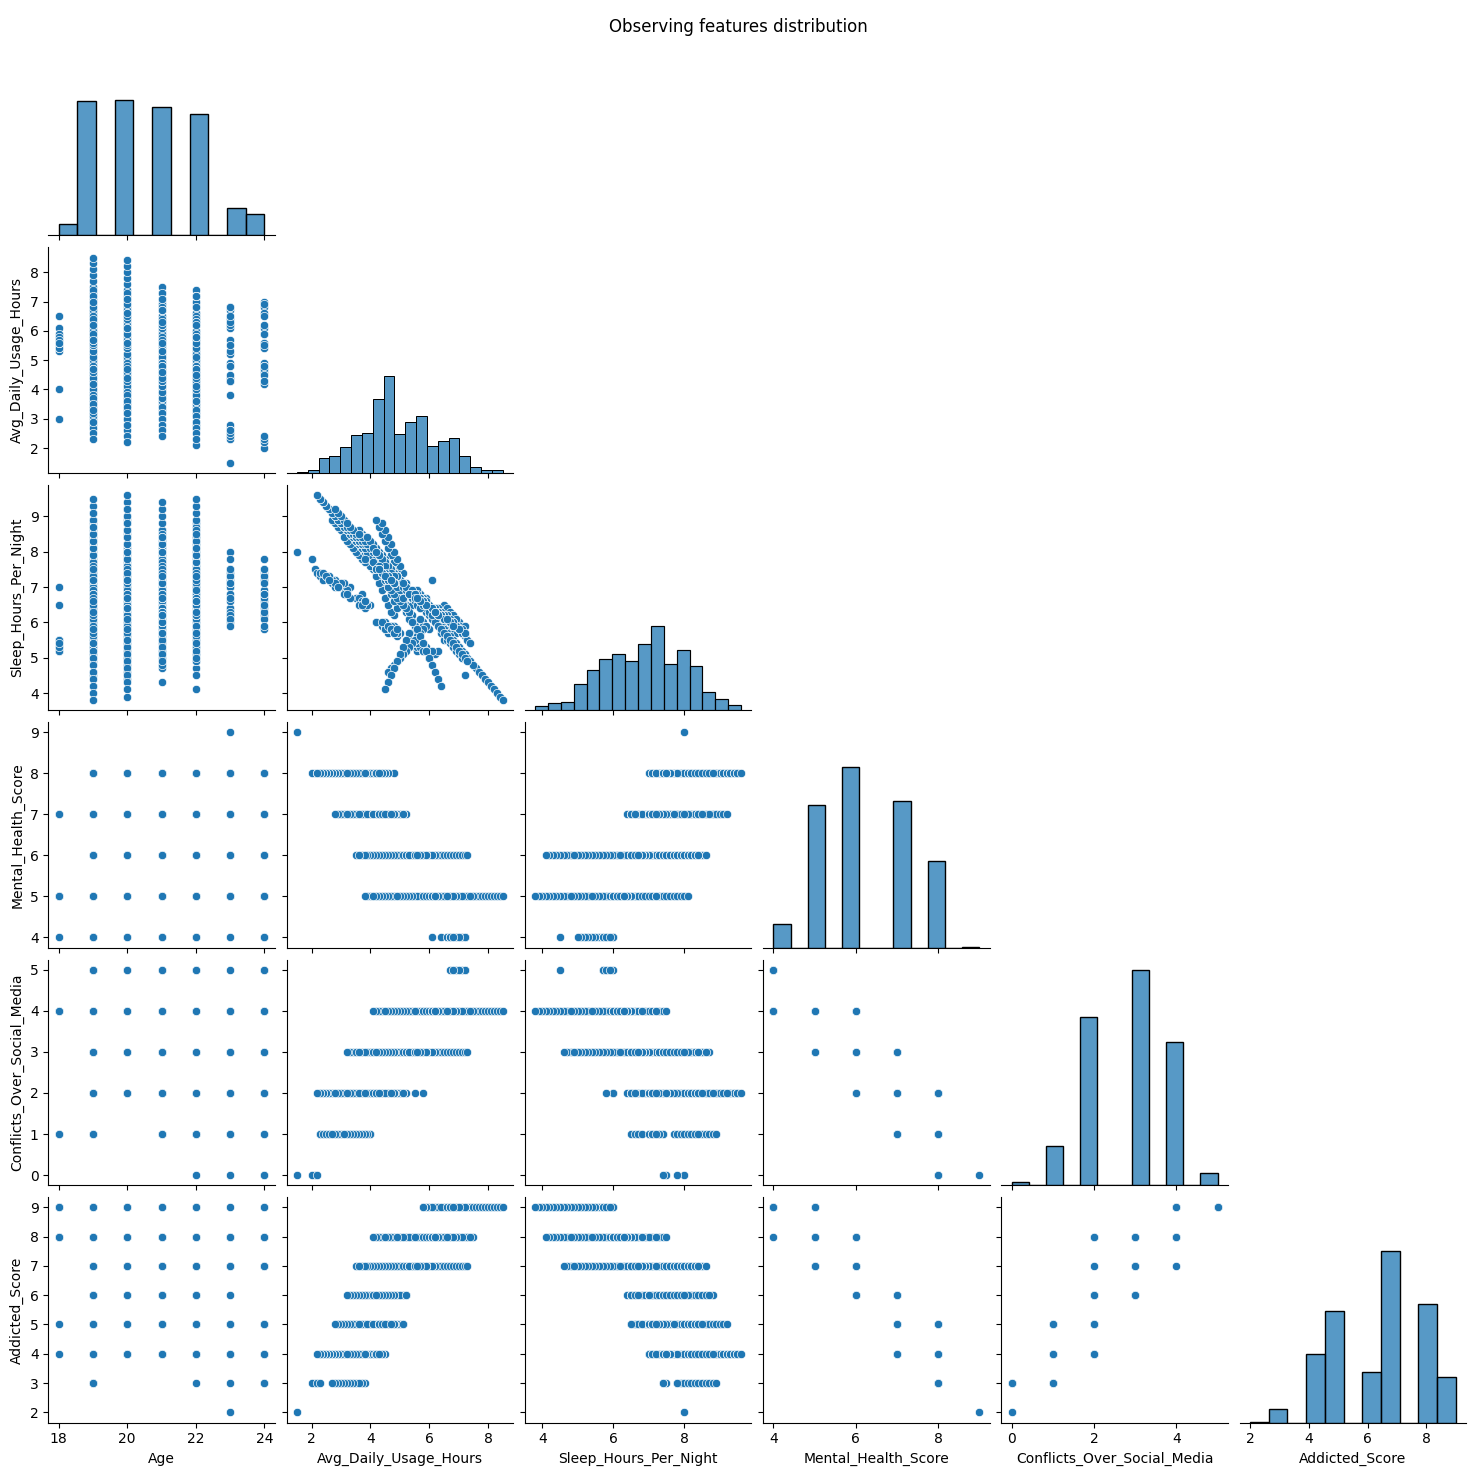

In [7]:
import matplotlib.pyplot as plt

df_no_ids = df.drop(columns="Student_ID")

sns.pairplot(
    data=df_no_ids,
    corner=True,
)
plt.suptitle("Observing features distribution")
plt.show()